# Conditional Variational AutoEncoder (cVAE)
### Butterfly Dataset — 75-class conditional image generation

Follows the AUTOENCODER.py example pattern from `exemplos_modelos/`:
- Class-based model definition (Encoder / Decoder / cVAE)
- `train()` function that returns model + loss history
- Visualisation helpers mirroring `plot_results()`

Extensions over the base example:
- **Convolutional** encoder/decoder (instead of linear)
- **Class conditioning** via `nn.Embedding` (required for 75-class generation)
- **ELBO loss** = MSE + λ·Perceptual + β·KL (β annealed to avoid posterior collapse)
- **GPU training** (cuda → mps → cpu fallback, same as all example files)


In [1]:
import os, sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import models, transforms
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd

# ── Device setup (following exemplos_modelos pattern) ──────────────────────
device = torch.device(
    "cuda"  if torch.cuda.is_available()  else
    "mps"   if torch.backends.mps.is_available() else
    "cpu"
)
print(f"Using device: {device}")

Using device: cuda


In [2]:
# ── Add project root to path so src/ is importable ────────────────────────
sys.path.insert(0, os.path.abspath(".."))

from src.dataset import (
    ButterflyDataset, get_splits, build_label_map,
    get_train_transform, get_eval_transform, make_dataloader,
)
from src.utils import (
    save_checkpoint, load_checkpoint,
    visualize_grid, plot_losses,
    EarlyStopping, get_device, tensor_to_pil, denormalize,
)
from src.metrics import compute_fid, compute_inception_score, compute_ssim

In [3]:
# ── Configuration ──────────────────────────────────────────────────────────
BASE_DIR   = os.path.abspath("..")
IMG_DIR    = os.path.join(BASE_DIR, "aca-butterflies", "train")
CSV_PATH   = os.path.join(BASE_DIR, "aca-butterflies", "train.csv")
SAVE_DIR   = os.path.join(BASE_DIR, "data", "generated", "cvae")
MODEL_PATH = os.path.join(BASE_DIR, "saved_models", "cvae_checkpoint.pth")
os.makedirs(SAVE_DIR, exist_ok=True)

# Hyperparameters
IMAGE_SIZE    = 64
BATCH_SIZE    = 64
LATENT_DIM    = 128
NUM_CLASSES   = 75
EMB_DIM       = 32

# Training
LR            = 3e-4
WEIGHT_DECAY  = 1e-5
NUM_EPOCHS    = 150      # extended: model hadn't plateaued at 100
ES_PATIENCE   = 30       # more patience to let LR scheduler do its work

# LR scheduler: halve LR when val_recon doesn't improve for LR_PATIENCE epochs
LR_PATIENCE   = 10
LR_FACTOR     = 0.5
LR_MIN        = 1e-6     # floor so LR doesn't go to zero

# Loss weights
BETA          = 0.5
LAMBDA_PERC   = 0.001
GRAD_CLIP     = 1.0
FREE_BITS     = 0.2

In [4]:
# ── Data loading ───────────────────────────────────────────────────────────
label_to_idx, idx_to_label = build_label_map(CSV_PATH)
num_classes = len(label_to_idx)
print(f"Classes: {num_classes}")

train_df, val_df, test_df = get_splits(CSV_PATH, train_ratio=0.70, val_ratio=0.15, seed=42)
print(f"Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}")

train_set = ButterflyDataset(train_df, IMG_DIR, label_to_idx, transform=get_train_transform(IMAGE_SIZE))
val_set   = ButterflyDataset(val_df,   IMG_DIR, label_to_idx, transform=get_eval_transform(IMAGE_SIZE))
test_set  = ButterflyDataset(test_df,  IMG_DIR, label_to_idx, transform=get_eval_transform(IMAGE_SIZE))

train_loader = make_dataloader(train_set, BATCH_SIZE, shuffle=True)
val_loader   = make_dataloader(val_set,   BATCH_SIZE, shuffle=False)
test_loader  = make_dataloader(test_set,  BATCH_SIZE, shuffle=False)

print(f"Batches — Train: {len(train_loader)}  Val: {len(val_loader)}")

Classes: 75
Train: 3,606  Val: 745  Test: 848
Batches — Train: 57  Val: 12


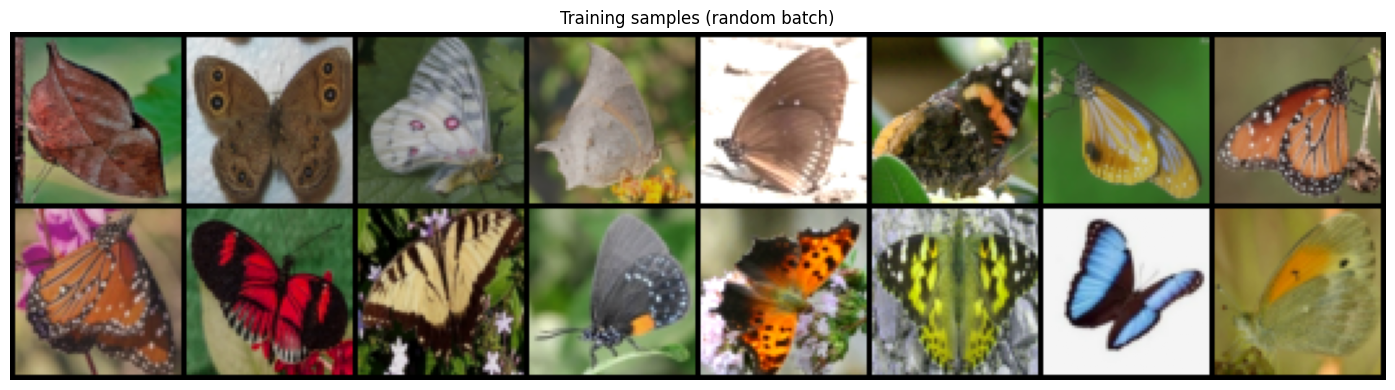

In [5]:
# ── Visualise a training batch ─────────────────────────────────────────────
imgs, labs = next(iter(train_loader))
visualize_grid(imgs, labs, idx_to_label, n=16, nrow=8,
               title="Training samples (random batch)", denorm=True)

## Model Architecture

### Encoder
`Image (3×64×64)` + `class embedding (64-dim)`
→ Conv blocks (3→64→128→256, stride-2) → Flatten → FC(16448, 512) → **μ, log σ²** (128-dim each)

### Decoder
`z (128-dim)` + `class embedding (64-dim)`
→ FC(192, 16384) → Reshape (256×8×8) → ConvTranspose blocks (256→128→64→3) → **Tanh output**

Conditioning is applied via `nn.Embedding(75, 64)` injected at both the encoder (after flattening)
and the decoder (before the FC projection), following the approach from the course examples.


In [6]:
class Encoder(nn.Module):
    """Convolutional encoder with class conditioning."""

    def __init__(self, latent_dim=LATENT_DIM, num_classes=NUM_CLASSES, emb_dim=EMB_DIM):
        super().__init__()
        self.class_emb = nn.Embedding(num_classes, emb_dim)

        # Conv feature extractor — mirrors Discriminator pattern in GAN.py
        self.conv = nn.Sequential(
            nn.Conv2d(3, 64, 4, stride=2, padding=1),           # 64→32
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),          # 32→16
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, stride=2, padding=1),         # 16→8
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.flat_dim = 256 * 8 * 8                              # 16384

        self.fc = nn.Sequential(
            nn.Linear(self.flat_dim + emb_dim, 512),
            nn.ReLU(inplace=True),
        )
        self.fc_mu     = nn.Linear(512, latent_dim)
        self.fc_logvar = nn.Linear(512, latent_dim)

    def forward(self, x, label):
        h = self.conv(x).view(x.size(0), -1)                    # (B, 16384)
        c = self.class_emb(label)                                # (B, emb_dim)
        h = self.fc(torch.cat([h, c], dim=1))                   # (B, 512)
        return self.fc_mu(h), self.fc_logvar(h)



In [7]:
class Decoder(nn.Module):
    """Convolutional decoder with class conditioning.
    Uses InstanceNorm instead of BatchNorm: InstanceNorm normalises per-sample,
    preserving class-specific features. BatchNorm averages across the batch
    which blurs class details when different butterfly species are in the same batch.
    """

    def __init__(self, latent_dim=LATENT_DIM, num_classes=NUM_CLASSES, emb_dim=EMB_DIM):
        super().__init__()
        self.class_emb = nn.Embedding(num_classes, emb_dim)
        self.fc = nn.Linear(latent_dim + emb_dim, 256 * 8 * 8)

        # ConvTranspose upsampler — mirrors Generator pattern in GAN.py
        # InstanceNorm2d(affine=True) preserves per-sample statistics → sharper class details
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),  # 8→16
            nn.InstanceNorm2d(128, affine=True),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),   # 16→32
            nn.InstanceNorm2d(64, affine=True),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 3, 4, stride=2, padding=1),     # 32→64
            nn.Tanh(),
        )

    def forward(self, z, label):
        c = self.class_emb(label)                                # (B, emb_dim)
        h = self.fc(torch.cat([z, c], dim=1))                   # (B, 256*8*8)
        h = h.view(-1, 256, 8, 8)                               # (B, 256, 8, 8)
        return self.deconv(h)                                    # (B, 3, 64, 64)



In [8]:
class ConditionalVAE(nn.Module):
    """cVAE: combines Encoder + reparameterisation trick + Decoder."""

    def __init__(self, latent_dim=LATENT_DIM, num_classes=NUM_CLASSES, emb_dim=EMB_DIM):
        super().__init__()
        self.encoder = Encoder(latent_dim, num_classes, emb_dim)
        self.decoder = Decoder(latent_dim, num_classes, emb_dim)
        self.latent_dim = latent_dim

    def reparameterize(self, mu, logvar):
        """z = mu + eps * sigma,  eps ~ N(0, I)"""
        # Clamp logvar to prevent exp() overflow → NaN
        logvar = logvar.clamp(-4, 15)
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x, label):
        mu, logvar = self.encoder(x, label)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z, label)
        return recon, mu, logvar.clamp(-4, 15)

    @torch.no_grad()
    def generate(self, labels: torch.Tensor) -> torch.Tensor:
        """Sample from the prior N(0, I) and decode for given class labels."""
        z = torch.randn(len(labels), self.latent_dim, device=labels.device)
        return self.decoder(z, labels)



In [9]:
class PerceptualLoss(nn.Module):
    """
    Feature-level loss using VGG16 up to relu2_2.
    Input tensors must be in [-1, 1] (will be rescaled internally).
    Mitigates the blurriness that plain MSE reconstruction causes in VAEs.
    """

    def __init__(self):
        super().__init__()
        vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT).features
        # Layers 0-8 correspond to relu2_2
        self.slice = nn.Sequential(*list(vgg.children())[:9])
        for p in self.slice.parameters():
            p.requires_grad = False
        # ImageNet normalisation buffers
        self.register_buffer("mean", torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer("std",  torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

    def forward(self, x, target):
        # [-1,1] → [0,1] → ImageNet normalised
        x      = ((x      + 1) / 2 - self.mean) / self.std
        target = ((target + 1) / 2 - self.mean) / self.std
        return F.mse_loss(self.slice(x), self.slice(target))



In [10]:
def vae_loss(recon, x, mu, logvar, perceptual_fn, beta=BETA, lambda_perc=LAMBDA_PERC):
    """
    ELBO loss for the cVAE.
    Fixed: Calculates sum over feature dimensions, and mean over the batch.
    """
    # 1. MSE: Sum over pixels (C, H, W), then mean over the batch (B)
    mse_per_sample = F.mse_loss(recon, x, reduction="none").view(x.size(0), -1).sum(dim=1)
    mse = mse_per_sample.mean()

    if lambda_perc > 0:
        perc = perceptual_fn(recon, x)
    else:
        perc = torch.zeros(1, device=recon.device)[0]
        
    recon_loss = mse + lambda_perc * perc

    # 2. KL Divergence: Apply free bits per dim, sum over latent dims, then mean over batch
    kl_per_dim = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())
    kl_per_dim = torch.clamp(kl_per_dim, min=FREE_BITS)
    kl = kl_per_dim.sum(dim=1).mean()

    # 3. Total Loss
    total = recon_loss + beta * kl
    return total, recon_loss, mse.item(), perc.item(), kl.item()

In [11]:
def train_cvae(model, train_loader, val_loader, perceptual_fn,
               num_epochs=NUM_EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY,
               es_patience=ES_PATIENCE, grad_clip=GRAD_CLIP, device=device):
    """
    Training loop for the cVAE.
    Follows the train() function structure from exemplos_modelos/AUTOENCODER.py.
    Uses a fixed beta=BETA (no annealing) for a stable KL signal from epoch 1.
    Early stopping and checkpointing use val_recon (MSE + λ·Perc, no KL).
    ReduceLROnPlateau halves the LR when val_recon stops improving — more
    effective than just adding more epochs at a fixed learning rate.
    """
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=LR_FACTOR,
        patience=LR_PATIENCE, min_lr=LR_MIN,
    )
    es = EarlyStopping(patience=es_patience, mode="min")

    model = model.to(device)
    perceptual_fn = perceptual_fn.to(device)

    train_losses, val_losses = [], []
    best_val_recon = float("inf")

    for epoch in range(num_epochs):
        # ── Train ─────────────────────────────────────────────────────────
        model.train()
        running_loss = 0.0
        for i, (imgs, labels) in enumerate(train_loader):
            imgs   = imgs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            recon, mu, logvar = model(imgs, labels)
            loss, recon_loss, mse, perc, kl = vae_loss(recon, imgs, mu, logvar,
                                                        perceptual_fn)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
            optimizer.step()
            running_loss += loss.item()

            if i % 50 == 0:
                current_lr = optimizer.param_groups[0]["lr"]
                print(f"[{epoch+1}/{num_epochs}][{i}/{len(train_loader)}] "
                      f"Loss: {loss.item():.4f}  MSE: {mse:.4f}  "
                      f"Perc: {perc:.4f}  KL: {kl:.4f}  lr: {current_lr:.2e}")

        avg_train = running_loss / len(train_loader)
        train_losses.append(avg_train)

        # ── Validate ──────────────────────────────────────────────────────
        model.eval()
        val_loss = 0.0
        val_recon_sum = 0.0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                recon, mu, logvar = model(imgs, labels)
                loss, recon_loss, *_ = vae_loss(recon, imgs, mu, logvar,
                                                perceptual_fn)
                val_loss      += loss.item()
                val_recon_sum += recon_loss.item()

        avg_val       = val_loss      / len(val_loader)
        avg_val_recon = val_recon_sum / len(val_loader)
        val_losses.append(avg_val)

        current_lr = optimizer.param_groups[0]["lr"]
        print(f"Epoch: {epoch+1}  Train Loss: {avg_train:.4f}  "
              f"Val Loss: {avg_val:.4f}  Val Recon: {avg_val_recon:.4f}  lr: {current_lr:.2e}")

        # Step scheduler on val_recon — reduces LR when plateau detected
        scheduler.step(avg_val_recon)

        if avg_val_recon < best_val_recon:
            best_val_recon = avg_val_recon
            save_checkpoint(model, MODEL_PATH, epoch=epoch + 1, val_loss=avg_val_recon)

        if es(avg_val_recon):
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    return model.to("cpu"), train_losses, val_losses



In [12]:
# ── Instantiate and train (mirrors AUTOENCODER.py usage pattern) ───────────
cvae = ConditionalVAE(LATENT_DIM, NUM_CLASSES, EMB_DIM)
perceptual_fn = PerceptualLoss()

print(f"cVAE parameters: {sum(p.numel() for p in cvae.parameters()):,}")

cvae, train_losses, val_losses = train_cvae(
    cvae, train_loader, val_loader, perceptual_fn,
    num_epochs=NUM_EPOCHS, device=device,
)

cVAE parameters: 12,498,115
[1/150][0/57] Loss: 8437.3906  MSE: 8424.5596  Perc: 29.9895  KL: 25.6017  lr: 3.00e-04
[1/150][50/57] Loss: 2168.7400  MSE: 2075.1780  Perc: 10.4788  KL: 187.1032  lr: 3.00e-04
Epoch: 1  Train Loss: 3572.0241  Val Loss: 2040.8797  Val Recon: 1951.2312  lr: 3.00e-04
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\cvae_checkpoint.pth
[2/150][0/57] Loss: 2014.2410  MSE: 1926.0120  Perc: 10.9722  KL: 176.4359  lr: 3.00e-04
[2/150][50/57] Loss: 1780.7172  MSE: 1680.3854  Perc: 11.2028  KL: 200.6411  lr: 3.00e-04
Epoch: 2  Train Loss: 1871.3342  Val Loss: 1636.9050  Val Recon: 1544.3049  lr: 3.00e-04
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\cvae_checkpoint.pth
[3/150][0/57] Loss: 1619.2704  MSE: 1524.5042  Perc: 10.6514  KL: 189.5113  lr: 3.00e-04
[3/150][50/57] Loss: 1442.0654  MSE: 1341.8728  Perc: 10.1371  KL: 200.3651  lr: 3.00e-04
Epoch: 3  Train Loss: 1536.0978  Val Loss: 1382.3654  Val Recon: 1279.1244

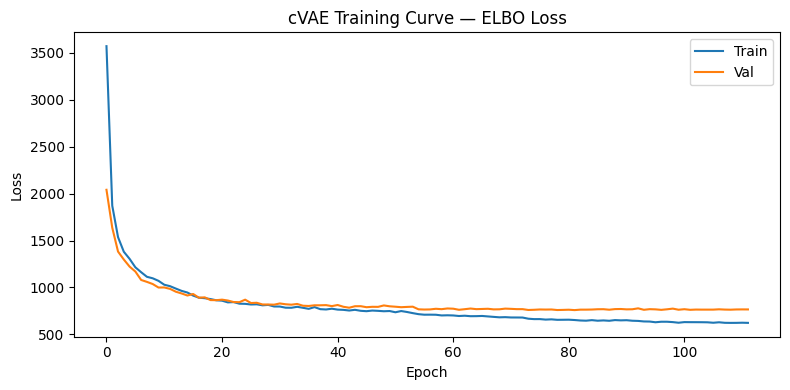

In [13]:
# ── Plot training curves (mirrors plot_results() in AUTOENCODER.py) ────────
plot_losses(train_losses, val_losses, title="cVAE Training Curve — ELBO Loss")

[checkpoint] loaded ← c:\Users\ricar\Downloads\TP2-Students\saved_models\cvae_checkpoint.pth


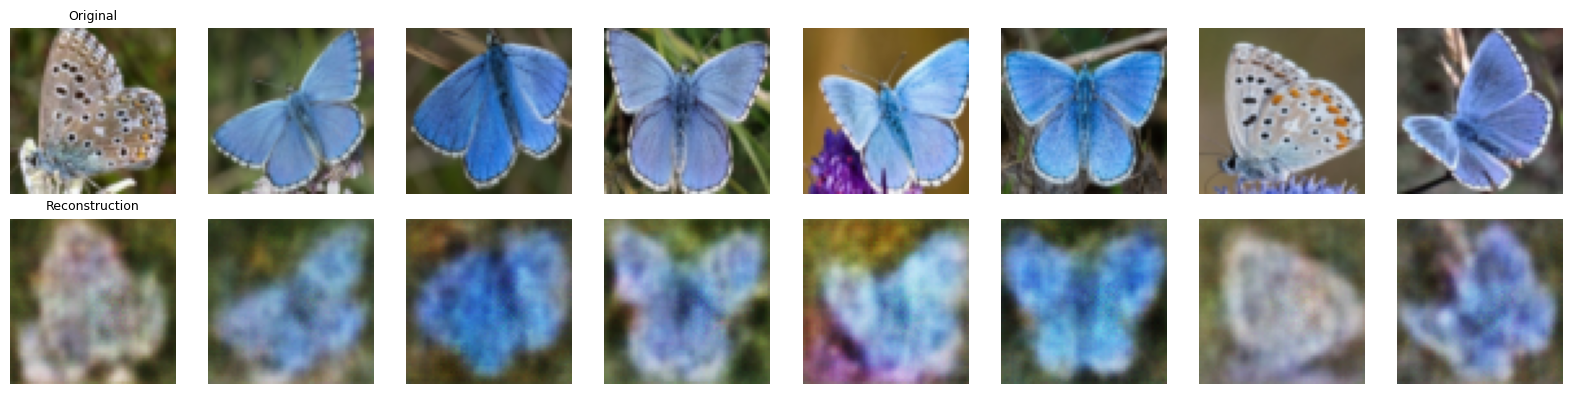

In [14]:
# ── Visualise reconstructions (side-by-side: original vs reconstruction) ───
# Follows the two-row grid style of AUTOENCODER.py plot_results()
load_checkpoint(MODEL_PATH, cvae, device)
cvae = cvae.to(device)
cvae.eval()

imgs, labels = next(iter(val_loader))
imgs, labels = imgs.to(device), labels.to(device)
with torch.no_grad():
    recon, _, _ = cvae(imgs, labels)

n = 8
fig, axes = plt.subplots(2, n, figsize=(2 * n, 4))
for i in range(n):
    for row, t in enumerate([imgs, recon]):
        img = (t[i].cpu() * 0.5 + 0.5).clamp(0, 1).permute(1, 2, 0).numpy()
        axes[row, i].imshow(img)
        axes[row, i].axis("off")
axes[0, 0].set_title("Original", fontsize=9)
axes[1, 0].set_title("Reconstruction", fontsize=9)
plt.tight_layout()
plt.show()

In [15]:
# ── Generate images per class (balance dataset to largest class count) ─────
class_counts = Counter(train_df["label"].tolist())
TARGET_PER_CLASS = max(class_counts.values())
print(f"Max images in one class: {TARGET_PER_CLASS}")
print(f"Will generate up to {TARGET_PER_CLASS} images per under-represented class")

cvae.eval()
generated_records = []

with torch.no_grad():
    for class_name, class_idx in label_to_idx.items():
        existing = class_counts.get(class_name, 0)
        n_gen = max(0, TARGET_PER_CLASS - existing)
        if n_gen == 0:
            continue

        # Generate in mini-batches to avoid OOM on large n_gen
        all_gen = []
        remaining = n_gen
        while remaining > 0:
            batch_n = min(remaining, BATCH_SIZE)
            lbl = torch.full((batch_n,), class_idx, dtype=torch.long, device=device)
            gen = cvae.generate(lbl)                # (batch_n, 3, 64, 64)
            all_gen.append(gen.cpu())
            remaining -= batch_n
        gen_imgs = torch.cat(all_gen, dim=0)        # (n_gen, 3, 64, 64)
        gen_imgs = (gen_imgs * 0.5 + 0.5).clamp(0, 1)  # [-1,1] → [0,1]

        for j, img_t in enumerate(gen_imgs):
            fname = f"cvae_{class_idx:03d}_{j:04d}.jpg"
            tensor_to_pil(img_t).save(os.path.join(SAVE_DIR, fname))
            generated_records.append({
                "filename": fname,
                "label": class_name,
                "img_dir": SAVE_DIR,
            })

        print(f"  [{class_idx:02d}] {class_name}: generated {n_gen}")

gen_df = pd.DataFrame(generated_records)
gen_df.to_csv(os.path.join(SAVE_DIR, "generated.csv"), index=False)
print(f"\nTotal generated: {len(gen_df):,}  |  Saved CSV → {SAVE_DIR}/generated.csv")

Max images in one class: 73
Will generate up to 73 images per under-represented class
  [00] ADONIS: generated 24
  [01] AFRICAN GIANT SWALLOWTAIL: generated 31
  [02] AMERICAN SNOOT: generated 32
  [03] AN 88: generated 26
  [04] APPOLLO: generated 23
  [05] ATALA: generated 17
  [06] BANDED ORANGE HELICONIAN: generated 20
  [07] BANDED PEACOCK: generated 27
  [08] BECKERS WHITE: generated 28
  [09] BLACK HAIRSTREAK: generated 26
  [10] BLUE MORPHO: generated 31
  [11] BLUE SPOTTED CROW: generated 25
  [12] BROWN SIPROETA: generated 18
  [13] CABBAGE WHITE: generated 23
  [14] CAIRNS BIRDWING: generated 27
  [15] CHECQUERED SKIPPER: generated 20
  [16] CHESTNUT: generated 26
  [17] CLEOPATRA: generated 22
  [18] CLODIUS PARNASSIAN: generated 24
  [19] CLOUDED SULPHUR: generated 22
  [20] COMMON BANDED AWL: generated 24
  [21] COMMON WOOD-NYMPH: generated 23
  [22] COPPER TAIL: generated 21
  [23] CRECENT: generated 20
  [24] CRIMSON PATCH: generated 33
  [25] DANAID EGGFLY: generated 

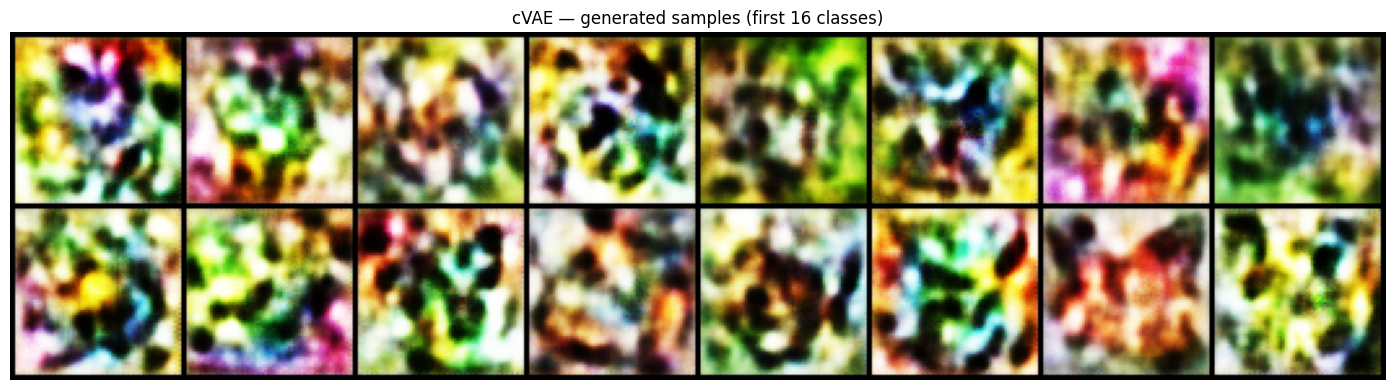

In [16]:
# ── Visualise a grid of generated samples (one per class, first 16) ────────
sample_labels = torch.arange(min(16, NUM_CLASSES), dtype=torch.long, device=device)
with torch.no_grad():
    samples = cvae.generate(sample_labels)
visualize_grid(samples.cpu(), sample_labels.cpu(), idx_to_label,
               n=16, nrow=8, title="cVAE — generated samples (first 16 classes)", denorm=True)

## Evaluation of Generative Quality

| Metric | Description | Applies to |
|--------|-------------|------------|
| **FID** (lower is better) | Fréchet distance between Inception features of real vs. generated sets | cVAE |
| **IS** (higher is better) | Inception Score — measures sharpness and diversity | cVAE |
| **SSIM** (higher is better) | Structural similarity vs. nearest real image of the same class | cVAE only |

FID and IS are computed **globally** (all classes combined) because per-class sample counts (~69)
are too small for reliable per-class FID estimation (requires ≥2000 samples).


In [17]:
from torch.utils.data import TensorDataset

def collect_tensor(loader, max_n=None):
    """Collect all images from a DataLoader into one (N, C, H, W) tensor."""
    batches = []
    n = 0
    for imgs, _ in loader:
        batches.append(imgs)
        n += len(imgs)
        if max_n and n >= max_n:
            break
    t = torch.cat(batches, dim=0)
    return t[:max_n] if max_n else t

print("Collecting real training images…")
real_imgs = collect_tensor(train_loader)          # (N, 3, 64, 64) in [-1,1]

print("Collecting generated images…")
gen_transform = get_eval_transform(IMAGE_SIZE)
gen_set  = ButterflyDataset(gen_df, SAVE_DIR, label_to_idx, transform=gen_transform)
gen_dl   = make_dataloader(gen_set, BATCH_SIZE, shuffle=False)
gen_imgs = collect_tensor(gen_dl)

print(f"Real: {real_imgs.shape}  |  Generated: {gen_imgs.shape}")

Real: torch.Size([3606, 3, 64, 64])  |  Generated: torch.Size([1869, 3, 64, 64])


In [18]:
# ── FID ───────────────────────────────────────────────────────────────────
print("Computing FID…")
fid_score = compute_fid(real_imgs, gen_imgs, device=device)
print(f"FID: {fid_score:.2f}  (lower is better)")

Computing FID…
FID: 252.57  (lower is better)


In [19]:
# ── Inception Score ───────────────────────────────────────────────────────
print("Computing IS…")
is_mean, is_std = compute_inception_score(gen_imgs, device=device)
print(f"IS:  {is_mean:.3f} ± {is_std:.3f}  (higher is better)")

Computing IS…
IS:  2.241 ± 0.077  (higher is better)


In [20]:
# ── SSIM — pair generated with real images of the same class ──────────────
# For SSIM we need matching pairs: for each generated image, its class' real images
from torch.utils.data import DataLoader as DL

# Build per-class lists of real image tensors
per_class_real = {lbl: [] for lbl in label_to_idx.values()}
for imgs, labs in train_loader:
    imgs_01 = (imgs * 0.5 + 0.5).clamp(0, 1)   # to [0,1]
    for img, lbl in zip(imgs_01, labs):
        per_class_real[lbl.item()].append(img)

# For each generated image, pick the first real image of same class as pair
paired_real, paired_gen = [], []
for imgs, labs in gen_dl:
    imgs_01 = (imgs * 0.5 + 0.5).clamp(0, 1)
    for img, lbl in zip(imgs_01, labs):
        c = lbl.item()
        if per_class_real[c]:
            paired_real.append(per_class_real[c][0])
            paired_gen.append(img)

real_t = torch.stack(paired_real)
gen_t  = torch.stack(paired_gen)
print("Computing SSIM…")
ssim_score = compute_ssim(real_t, gen_t)
print(f"SSIM: {ssim_score:.4f}  (higher is better, range [-1, 1])")

print("\n=== cVAE Generative Quality Summary ===")
print(f"  FID  : {fid_score:.2f}")
print(f"  IS   : {is_mean:.3f} ± {is_std:.3f}")
print(f"  SSIM : {ssim_score:.4f}")

Computing SSIM…
SSIM: 0.0286  (higher is better, range [-1, 1])

=== cVAE Generative Quality Summary ===
  FID  : 252.57
  IS   : 2.241 ± 0.077
  SSIM : 0.0286
